In [ ]:
import numpy as np
import sys
sys.path.append('./')

from code_plots import plot_phase_diagram
from code_load_data import get_all_data

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

fig_path = f"{figures_path}/phase_diagram/XXXXX"

In [ ]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

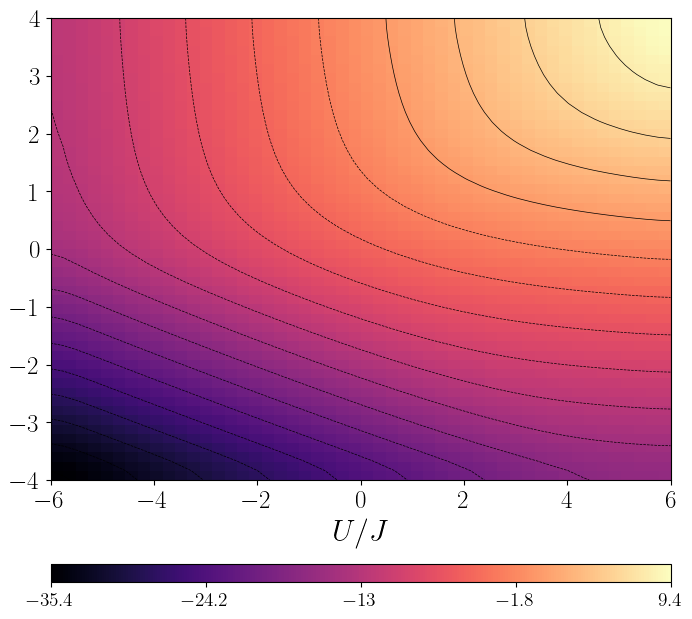

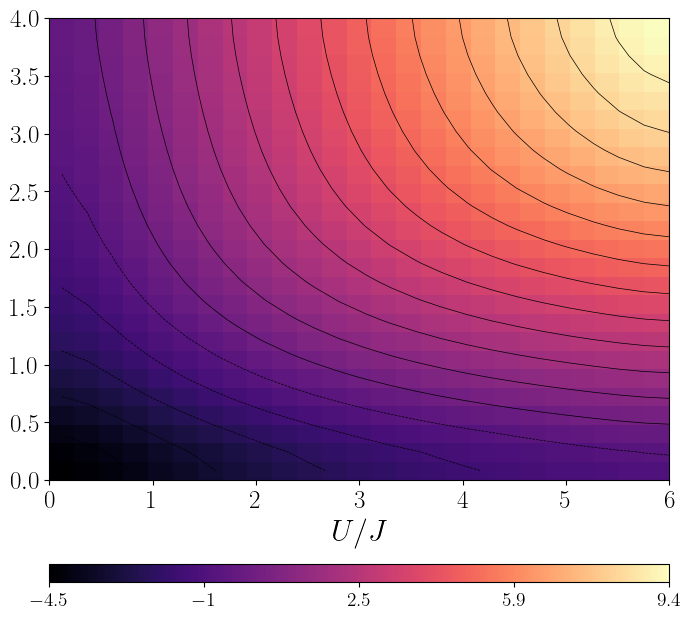

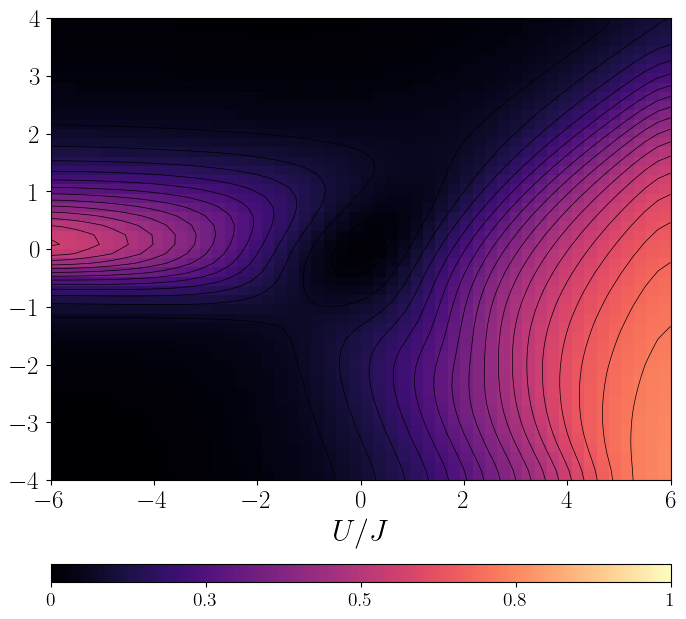

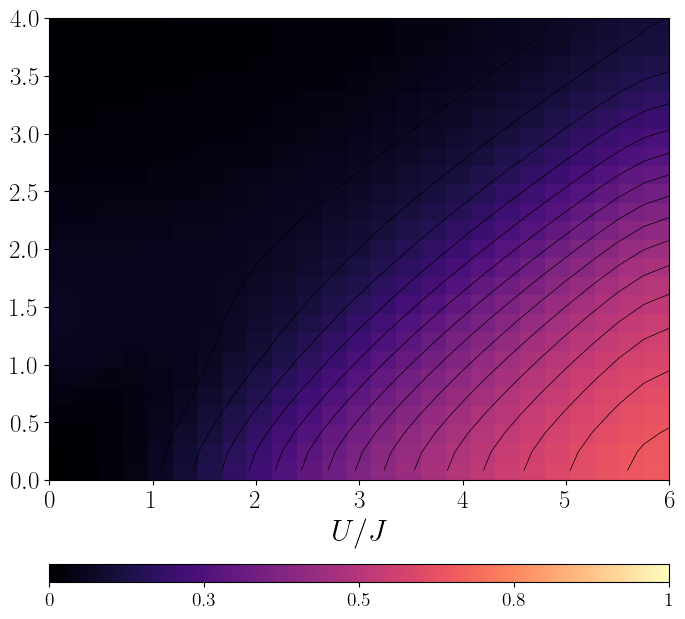

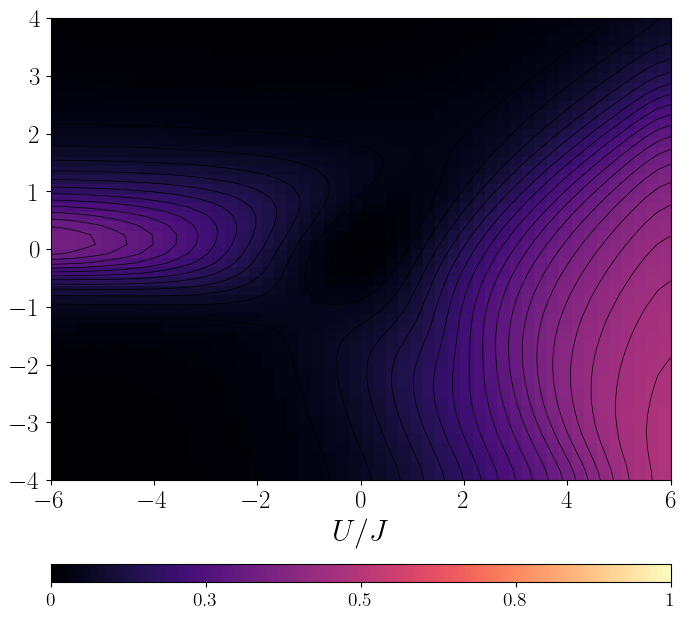

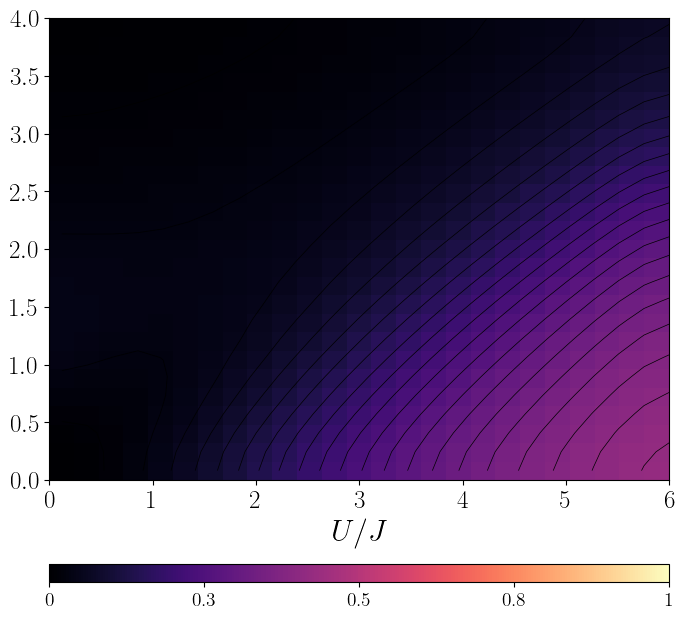

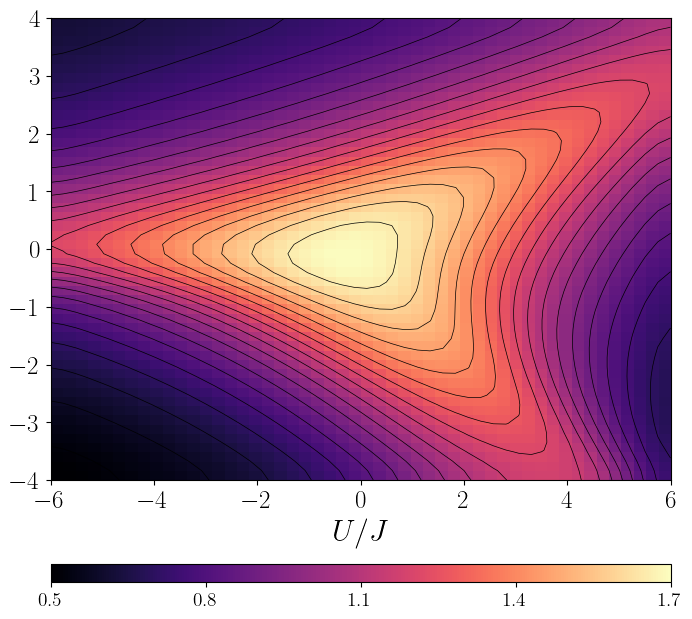

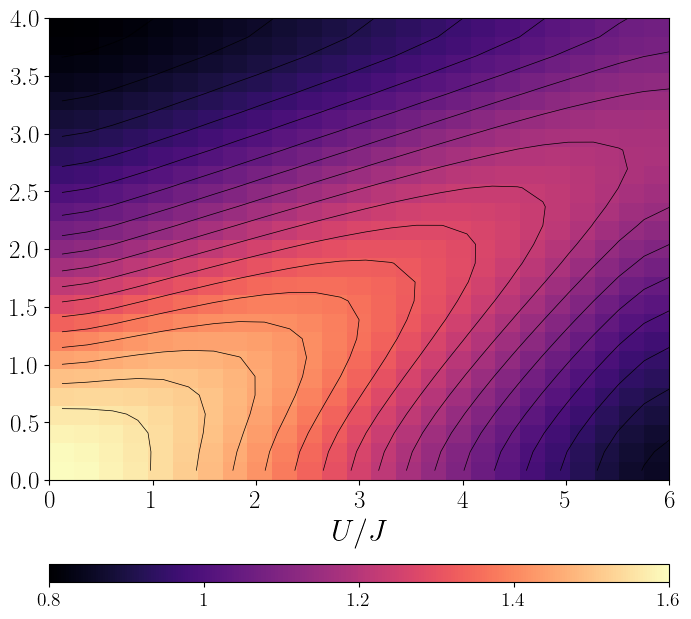

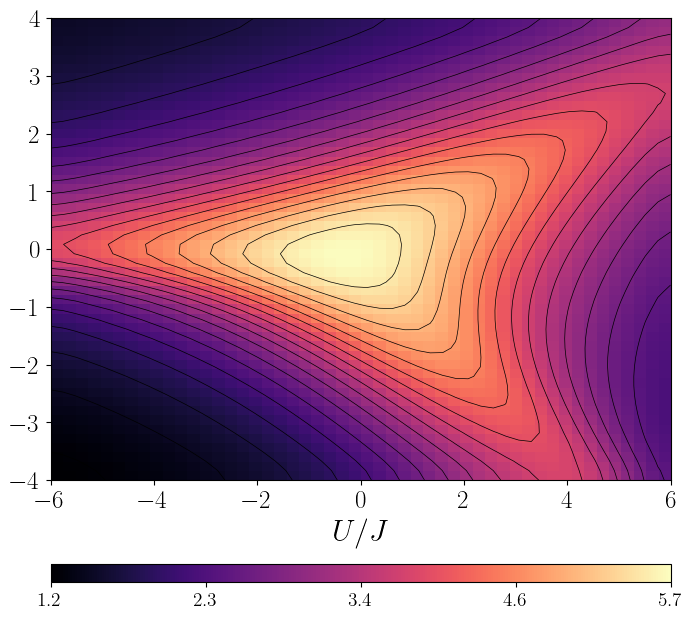

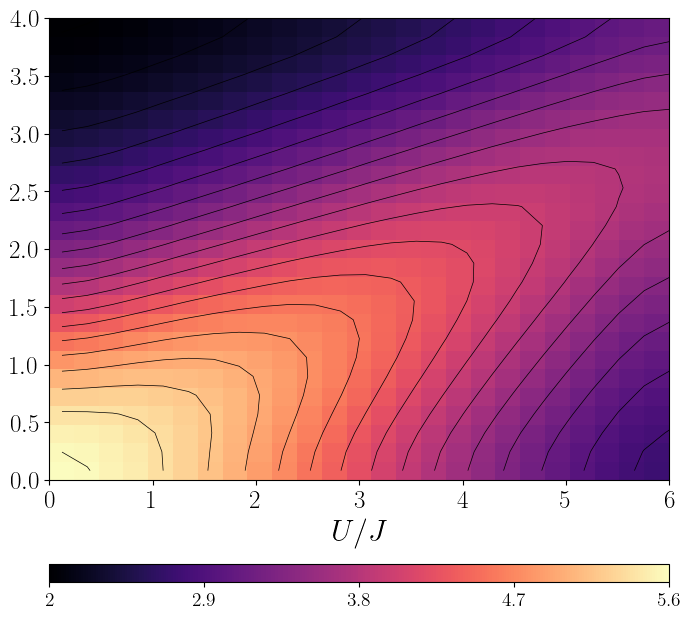

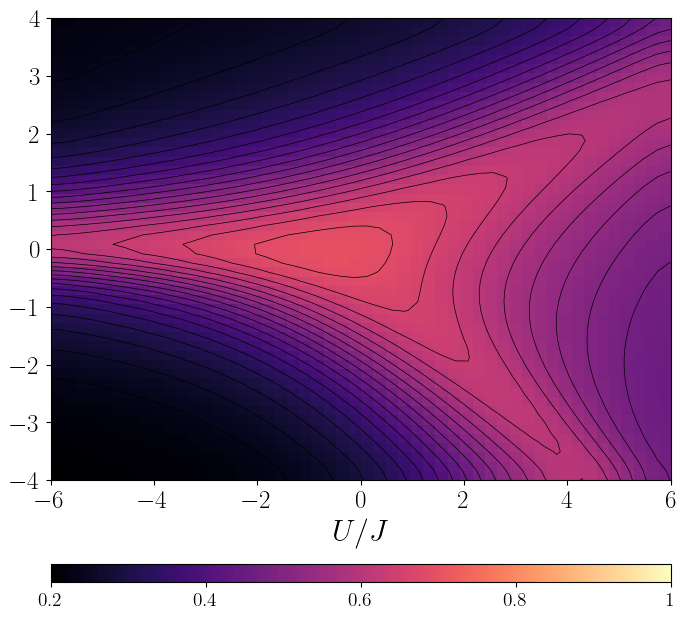

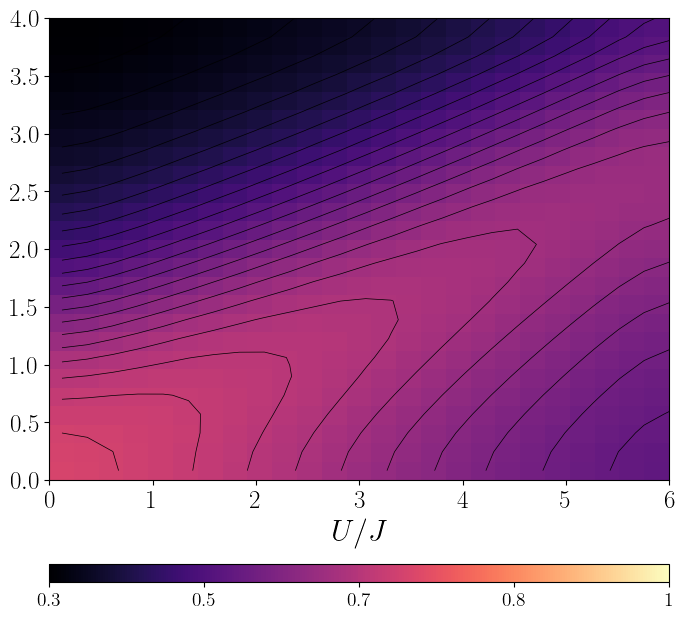

In [ ]:
L = 5
N_Points = 50

U_vals, V_vals, E_p, Q_2, quantum_coherence_1, quantum_coherence_2, avg_linear_entropy, E_GS, magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = get_all_data(results, model, exec, L, N_Points)

plot_phase_diagram(E_GS, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_\text{GS}$", 
                   fig_path.replace("XXXXX", f"E_GS_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")

plot_phase_diagram(E_GS, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_\text{GS}$", 
                   fig_path.replace("XXXXX", f"E_GS_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma")

plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)


plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")

plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma")


plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")
plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma")


plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

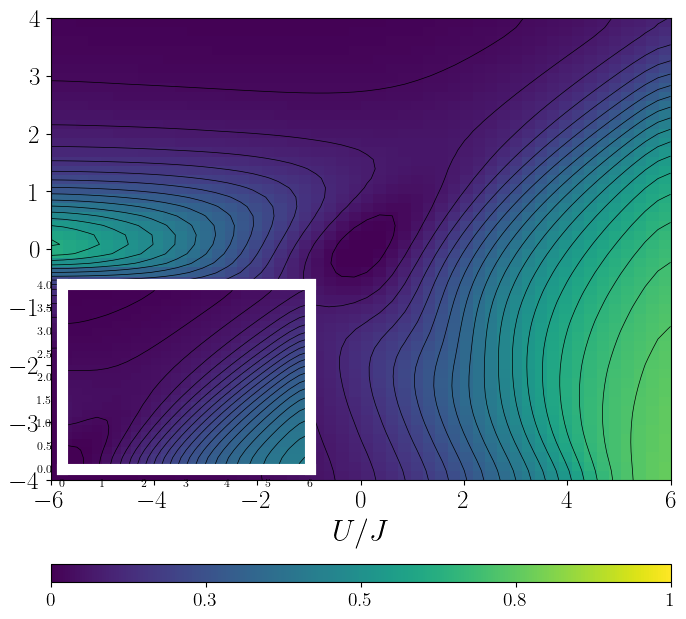

In [ ]:
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Rectangle

L = 5
N_Points = 50

U_vals, V_vals, E_p, Q_2, quantum_coherence_1, quantum_coherence_2, avg_linear_entropy, E_GS, magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = get_all_data(results, model, exec, L, N_Points)

# --- parameters ---
sigma_smoothing    = 1.5
num_contour_levels = 20
num_ticks = 5

# precompute extents & mesh
U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_vals)

# --- Mask and smoothing ---
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
mask_V = (V_vals >= V_min) & (V_vals <= V_max)

U_vals_new = U_vals[mask_U]
V_vals_new = V_vals[mask_V]

masked_measure = Q_2[np.ix_(mask_V, mask_U)]
smoothed_measure = gaussian_filter(masked_measure, sigma=sigma_smoothing)

X, Y = np.meshgrid(U_vals, V_vals)

# --- Normalization ---
vmin = np.nanmin(smoothed_measure)
vmax = 1.0 # np.nanmax(smoothed_measure)
norm = Normalize(vmin=vmin, vmax=vmax)

# helper to draw an imshow+contour
def draw_map(ax, data, X, Y, U_min, U_max, V_min, V_max, norm):
    sm = gaussian_filter(data, sigma=sigma_smoothing)
    im = ax.imshow(data, origin="lower",
                   extent=[U_min, U_max, V_min, V_max],
                   aspect="auto", cmap=theme, norm=norm)
    ax.contour(X, Y, sm, levels=num_contour_levels, colors='k', linewidths=0.5)
    ax.tick_params(labelsize=8)
    return im

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# main 1: Q2
imQ2 = draw_map(ax, Q_2, X, Y, U_min, U_max, V_min, V_max, norm)

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.set_xlabel(r"$U/J$", fontsize=22)

# inset for E_p
axins1 = inset_axes(ax, width="40%", height="40%", loc="lower left")

# give the inset a white background and white border
axins1.set_facecolor("white")
for spine in axins1.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(8)

U_min = 0.0
U_max = np.max(U_vals)
V_min = 0.0
V_max = np.max(V_vals)

# --- Mask and smoothing ---
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
mask_V = (V_vals >= V_min) & (V_vals <= V_max)

U_vals_new = U_vals[mask_U]
V_vals_new = V_vals[mask_V]

E_p_masked = E_p[np.ix_(mask_V, mask_U)]

U_vals_new = U_vals[mask_U]
V_vals_new = V_vals[mask_V]

X, Y = np.meshgrid(U_vals_new, V_vals_new)
draw_map(axins1, E_p_masked,  X, Y, 0.0, U_max, 0.0, V_max, norm)

# axins1.set_xticks([])
# axins1.set_yticks([])
axins1.set_xlabel("")
axins1.set_ylabel("")






# --- COLORBAR ON BOTTOM ---
pos = ax.get_position()
cax = fig.add_axes([pos.x0, -0.06, pos.width, 0.03])

ticks = np.linspace(vmin, vmax, num_ticks)

cbar = fig.colorbar(imQ2, cax=cax, orientation="horizontal", ticks=ticks, boundaries=np.linspace(vmin, vmax, 256))
cbar.ax.xaxis.set_ticks_position("bottom")

# --- Fixed decimal formatting for clean tick labels ---
def clean_tick(x, _):
    # format to one decimal place and remove trailing .0 if unnecessary
    s = f"{x:.1f}"
    if s.endswith(".0"):
        s = s[:-2]
    return f"${s}$"

cbar.ax.xaxis.set_major_formatter(FuncFormatter(clean_tick))
cbar.ax.tick_params(labelsize=14)

# save & show
# plt.savefig(f"{figures_path}/{model}_{exec}/big_Q2_C2_with_insets_L={L}.png", dpi=300, bbox_inches="tight")
plt.show()

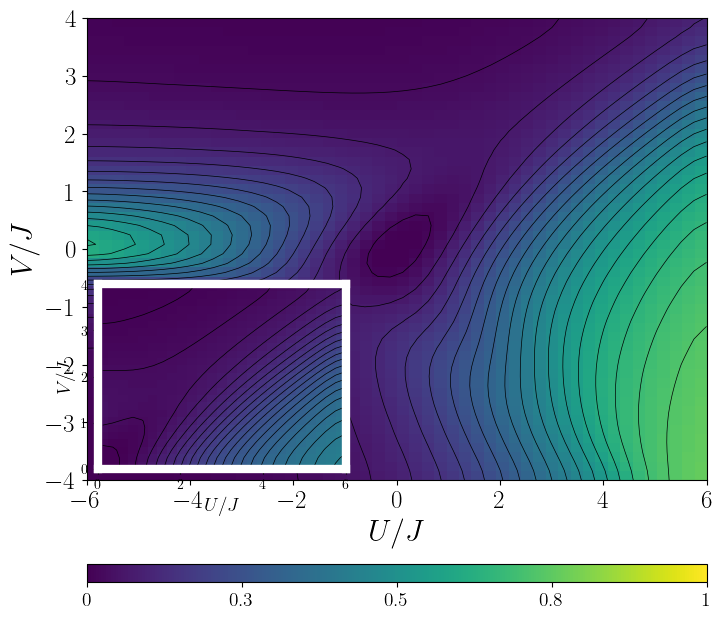

In [ ]:
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Rectangle
import numpy as np

L = 5
N_Points = 50

U_vals, V_vals, E_p, Q_2, quantum_coherence_1, quantum_coherence_2, avg_linear_entropy, E_GS, magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = get_all_data(results, model, exec, L, N_Points)

# --- parameters ---
sigma_smoothing    = 1.5
num_contour_levels = 20
num_ticks = 5

# precompute extents & mesh
U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_vals)

# --- Mask and smoothing ---
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
mask_V = (V_vals >= V_min) & (V_vals <= V_max)

U_vals_new = U_vals[mask_U]
V_vals_new = V_vals[mask_V]

masked_measure = Q_2[np.ix_(mask_V, mask_U)]
smoothed_measure = gaussian_filter(masked_measure, sigma=sigma_smoothing)

X, Y = np.meshgrid(U_vals, V_vals)

# --- Normalization ---
vmin = np.nanmin(smoothed_measure)
vmax = 1.0 # np.nanmax(smoothed_measure)
norm = Normalize(vmin=vmin, vmax=vmax)

# helper to draw an imshow+contour
def draw_map(ax, data, X, Y, U_min, U_max, V_min, V_max, norm):
    sm = gaussian_filter(data, sigma=sigma_smoothing)
    im = ax.imshow(data, origin="lower",
                   extent=[U_min, U_max, V_min, V_max],
                   aspect="auto", cmap=theme, norm=norm)
    ax.contour(X, Y, sm, levels=num_contour_levels, colors='k', linewidths=0.5)
    ax.tick_params(labelsize=8)
    return im

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# main 1: Q2
imQ2 = draw_map(ax, Q_2, X, Y, U_min, U_max, V_min, V_max, norm)

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.set_xlabel(r"$U/J$", fontsize=22)
ax.set_ylabel(r"$V/J$", fontsize=22)

# --- INSET FOR E_p ---
axins1 = inset_axes(ax, width="40%", height="40%", loc="lower left")

# --- White margin background (around ticks and labels) ---
# this adds a white rectangle *behind* the inset plot
# so ticks remain readable over busy background
bbox = axins1.get_position()
margin = 0.01  # relative to figure size, tweak if needed
rect = Rectangle(
    (bbox.x0 - margin, bbox.y0 - margin),
    bbox.width + 2*margin,
    bbox.height + 2*margin,
    transform=fig.transFigure,
    facecolor="white",
    edgecolor="none",
    zorder=axins1.get_zorder() - 1,
)
fig.patches.append(rect)

# --- Inset visual style ---
axins1.set_facecolor("white")
for spine in axins1.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(6)

U_min = 0.0
U_max = np.max(U_vals)
V_min = 0.0
V_max = np.max(V_vals)
# --- Mask and smoothing ---
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
mask_V = (V_vals >= V_min) & (V_vals <= V_max)

U_vals_new = U_vals[mask_U]
V_vals_new = V_vals[mask_V]

E_p_masked = E_p[np.ix_(mask_V, mask_U)]

U_vals_new = U_vals[mask_U]
V_vals_new = V_vals[mask_V]

X, Y = np.meshgrid(U_vals_new, V_vals_new)
draw_map(axins1, E_p_masked, X, Y, 0.0, U_max, 0.0, V_max, norm)

axins1.set_xlabel(r"$U/J$", fontsize = 14)
axins1.set_ylabel(r"$V/J$"  , fontsize = 14)
axins1.tick_params(labelsize=10, colors="black")

# --- COLORBAR ON BOTTOM ---
pos = ax.get_position()
cax = fig.add_axes([pos.x0, -0.06, pos.width, 0.03])

ticks = np.linspace(vmin, vmax, num_ticks)

cbar = fig.colorbar(imQ2, cax=cax, orientation="horizontal", ticks=ticks, boundaries=np.linspace(vmin, vmax, 256))
cbar.ax.xaxis.set_ticks_position("bottom")

# --- Fixed decimal formatting for clean tick labels ---
def clean_tick(x, _):
    s = f"{x:.1f}"
    if s.endswith(".0"):
        s = s[:-2]
    return f"${s}$"

cbar.ax.xaxis.set_major_formatter(FuncFormatter(clean_tick))
cbar.ax.tick_params(labelsize=14)
# plt.savefig(f"{figures_path}/{model}_{exec}/big_Q2_C2_with_insets_L={L}.png", dpi=300, bbox_inches="tight")
plt.show()

## Even chain

In [ ]:
L = 10
N_Points = 70
U_vals, V_vals, E_p, Q_2, quantum_coherence_1, quantum_coherence_2, avg_linear_entropy, E_GS, magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = get_all_data(results, model, exec, L, N_Points)


plot_phase_diagram(E_GS, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_\text{GS}$", 
                   fig_path.replace("XXXXX", f"E_GS_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")
plot_phase_diagram(E_GS, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_\text{GS}$", 
                   fig_path.replace("XXXXX", f"E_GS_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma")

plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)


plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")

plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma")


plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")
plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma")


plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}.pdf"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}_mask.pdf"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)